<a href="https://colab.research.google.com/github/AkimzhanRakhimov/Blood_Cell_Clasificator/blob/main/blood_cells_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports
from google.colab import drive
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
from torch import nn
from pathlib import Path
import os
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms


In [2]:
# config
device="cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE=32
torch.manual_seed(42)
torch.cuda.manual_seed(42)

drive.mount("/content/drive")
train_dataset_path="/content/drive/MyDrive/blood_cells_dataset/dataset2-master/dataset2-master/images/TRAIN/"
test_dataset_path="/content/drive/MyDrive/blood_cells_dataset/dataset2-master/dataset2-master/images/TEST/"
MODEL_SAVE_PATH="/content/drive/MyDrive/blood_cells_dataset/dataset2-master/dataset2-master/images/model.pth"

Mounted at /content/drive


In [ ]:
# archive unpacking
# import zipfile
# ZIP="/content/drive/MyDrive/blood_cells_dataset/archive.zip"
# with zipfile.ZipFile("/content/drive/MyDrive/blood_cells_dataset/archive.zip","r") as zip_ref:
#   zip_ref.extractall("/content/drive/MyDrive/blood_cells_dataset/")



In [3]:
label_classes={
    "EOSINOPHIL":0,
    "LYMPHOCYTE":1,
    "MONOCYTE":2,
    "NEUTROPHIL":3
}

In [4]:
# dataset processing class
class CellDataset(Dataset):
  def __init__(self,root_dir,label_classes,transform=None):
    self.transform=transform
    self.samples=[]

    for cell_type,label in label_classes.items():
      directory=Path(root_dir)/cell_type
      for file_path in directory.iterdir():
        self.samples.append((file_path,label))
  def __len__(self):
    return len(self.samples)

  def __getitem__(self, index):
    image_path,label=self.samples[index]
    image=Image.open(image_path).convert("RGB")

    if self.transform:
      image=self.transform(image)
    return image, label

In [5]:
# transform img to tensor
transform=transforms.Compose([transforms.Resize((240,320)),
                             transforms.ToTensor()])
dataset=CellDataset(train_dataset_path,label_classes,transform)
# divide dataset into train and test subsets
train_size=int(0.8*len(dataset))
test_size=len(dataset)-train_size
train_dataset,test_dataset=random_split(dataset,[train_size,test_size])
# create dataloader
train_dataloader=DataLoader(train_dataset,shuffle=True,batch_size=BATCH_SIZE,num_workers=4,pin_memory=True)
test_dataloader=DataLoader(test_dataset,shuffle=True,batch_size=BATCH_SIZE,num_workers=4,pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


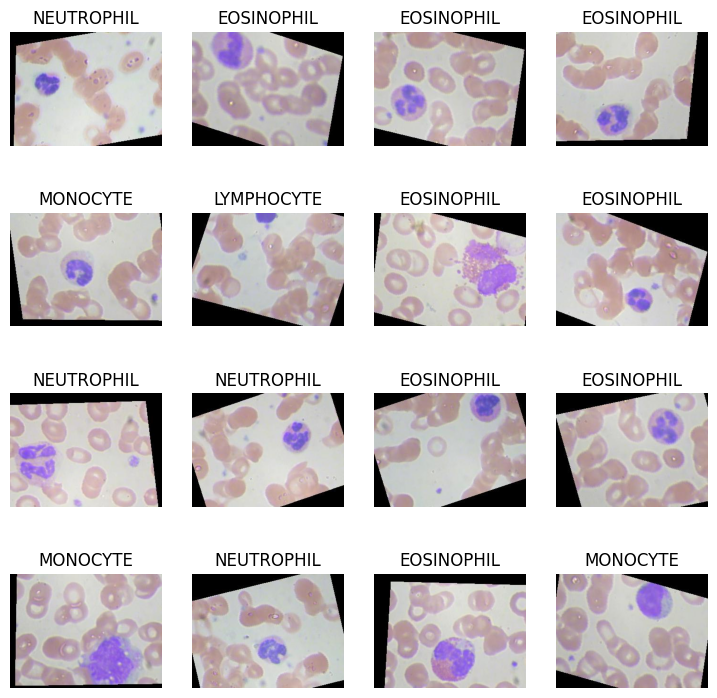

In [6]:
# show image
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(dataset),size=[1]).item()
  img=dataset[random_idx][0].permute(1,2,0)
  fig.add_subplot(rows,cols,i)
  plt.axis(False)
  plt.imshow(img)
  key = next(key for key, value in label_classes.items() if value == dataset[random_idx][1])
  plt.title(key)



In [6]:
# neural network consists of 2 convolutional blocks and 1 linear layer
class BloodCellClassifierV0(nn.Module):
  def __init__(self,input_features:int,hidden_dim:int,output_features:int):
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_features,
                  out_channels=hidden_dim,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2))
    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_dim,
                  out_channels=hidden_dim,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2))
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.5),
        nn.Linear(in_features=hidden_dim*4800,
                  out_features=output_features),
    )

  def forward(self,x):
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [7]:
# create model instance
model=BloodCellClassifierV0(3,10,len(label_classes))
model.to(device)

BloodCellClassifierV0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequen

In [8]:
# choose an optimizer and loss function
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()

In [11]:
# custom accuracy
def accuracy_fn(y_pred,y_true):
  correct=torch.eq(y_pred,y_true).sum().item()
  acc=(correct/len(y_true))*100
  return acc


In [16]:
# training and evaluating loop
epochs=10

for epoch in range(epochs):
  model.train()
  train_loss,train_acc=0,0
  print(f"Epoch: {epoch+1}/{epochs}")
  for batch,(X,y_true) in enumerate(train_dataloader):
    X,y_true=X.to(device),y_true.to(device)
    y_pred=model(X)
    loss=loss_fn(y_pred,y_true)
    train_loss+=loss
    train_acc+=accuracy_fn(y_pred.argmax(dim=1),y_true)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch%20==0:
      print(f"Loooked at {batch*BATCH_SIZE}/{len(train_dataloader)*BATCH_SIZE} samples")
      print(f"Predicted labels: {y_pred.argmax(dim=1)}")
      print(f"True labels: {y_true}")
  train_loss/=len(train_dataloader)
  train_acc/=len(train_dataloader)
  test_loss,test_acc=0,0
  model.eval()
  with torch.inference_mode():
    for batch,(X_test,y_test_true) in enumerate(test_dataloader):
      X_test,y_test_true=X_test.to(device),y_test_true.to(device)
      y_test_pred=model(X_test)
      test_loss+=loss_fn(y_test_pred,y_test_true)
      test_acc+=accuracy_fn(y_test_pred.argmax(dim=1),y_test_true)
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)
  print(f"Epoch: {epoch+1}, Train Loss: {train_loss}, Test Loss: {test_loss}, Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")

Epoch: 1/10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loooked at 0/7968 samples
Predicted labels: tensor([3, 2, 2, 3, 0, 2, 2, 2, 3, 1, 0, 3, 1, 0, 3, 3, 3, 2, 2, 2, 2, 0, 3, 0,
        3, 3, 2, 2, 0, 2, 2, 3], device='cuda:0')
True labels: tensor([3, 2, 2, 3, 0, 2, 2, 2, 3, 1, 0, 3, 1, 0, 3, 3, 3, 2, 2, 2, 2, 3, 3, 0,
        3, 3, 2, 2, 3, 2, 2, 3], device='cuda:0')
Loooked at 640/7968 samples
Predicted labels: tensor([1, 2, 3, 3, 2, 1, 3, 3, 1, 2, 1, 1, 2, 3, 3, 0, 0, 0, 3, 0, 2, 2, 0, 2,
        2, 2, 2, 1, 0, 1, 0, 2], device='cuda:0')
True labels: tensor([1, 2, 3, 3, 1, 1, 3, 3, 1, 2, 1, 1, 0, 3, 3, 0, 0, 0, 0, 0, 2, 2, 0, 2,
        2, 2, 2, 1, 0, 1, 0, 1], device='cuda:0')
Loooked at 1280/7968 samples
Predicted labels: tensor([3, 0, 3, 3, 3, 1, 1, 1, 1, 2, 1, 2, 3, 3, 3, 1, 0, 0, 2, 3, 3, 2, 1, 3,
        0, 1, 1, 0, 0, 2, 3, 3], device='cuda:0')
True labels: tensor([3, 3, 3, 3, 3, 1, 1, 1, 1, 2, 1, 2, 3, 3, 3, 1, 0, 0, 2, 3, 3, 2, 1, 3,
        0, 1, 1, 0, 0, 2, 3, 3], device='cuda:0')
Loooked at 1920/7968 samples
Predicted label

KeyboardInterrupt: 

In [29]:
# save model
torch.save(obj=model.state_dict(),f=MODEL_SAVE_PATH),
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to /content/drive/MyDrive/blood_cells_dataset/dataset2-master/dataset2-master/images/model.pth


In [10]:
# load model
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

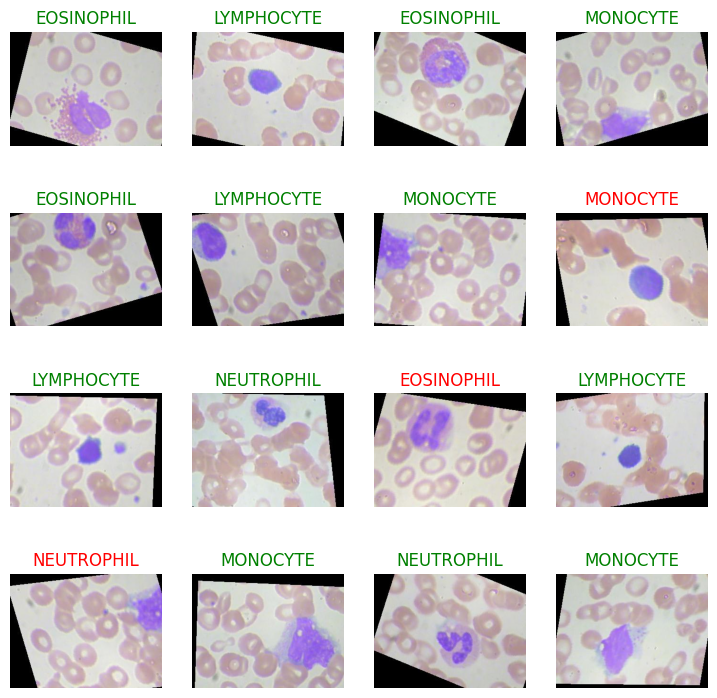

In [19]:
# check if random images belong to correct classes
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(test_dataset),size=[1]).item()
  model.eval()
  with torch.inference_mode():
    img=(test_dataset[random_idx][0]).unsqueeze(dim=0).to(device)
    y_pred=model(img).argmax(dim=1).item()
  y_true=test_dataset[random_idx][1]

  fig.add_subplot(rows,cols,i)
  img=img.squeeze(dim=0).permute(1,2,0).cpu()
  plt.axis(False)
  plt.imshow(img)
  key = next(key for key, value in label_classes.items() if value == y_pred)

  if y_true==y_pred:
    plt.title(key,c="g")
  else:
    plt.title(key,c="r")


In [21]:
# preparing confusion matrix
y_true=[]
y_preds=[]

model.eval()
with torch.inference_mode():
  for X,y in test_dataloader:
    X,y=X.to(device),y.to(device)
    y_true.append(y)
    y_pred=model(X).argmax(dim=1)
    y_preds.append(y_pred)
    # print(y_pred)
  y_true_tensor=torch.cat(y_true)
  y_pred_tensor=torch.cat(y_preds)

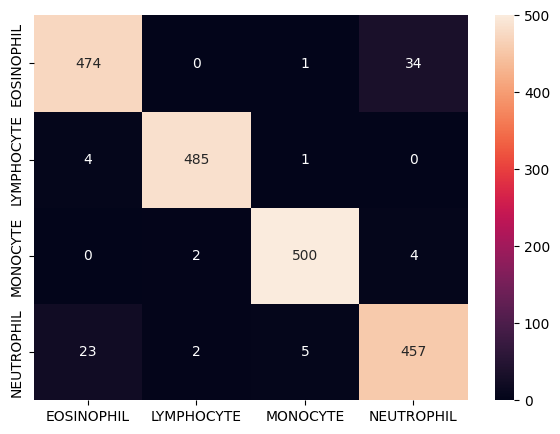

In [22]:
# showing a heatmap
data=np.zeros((4,4),dtype=int)

# counting true and false predictions
for idx,i in enumerate(y_true_tensor):
  data[i][(y_pred_tensor[idx])]+=1
labels=label_classes.keys()
plt.figure(figsize=(7,5))
# plotting the heatmap
hm = sns.heatmap(data=data,
                annot=True,xticklabels=labels,yticklabels=labels,fmt="d")

# displaying the plotted heatmap
plt.show()